In [1]:
import numpy as np
import ISSWlib as IS
import matplotlib.pyplot as plt
%matplotlib notebook

In [2]:
spectrum_folder = 'UPS_INKStandards/'
spectrum_filelist = spectrum_folder+'spectrum_files.txt'
spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

From getline0list: In  UPS_INKStandards/spectrum_files.txt , finding these spectra:
      B.10mL.txt
      A.14mL.txt
      C.20mL.txt
      C.34mL.txt
      C.50mL.txt
      C.57mL.txt


In [3]:
# Load in the blank, and check indices
lambda_nm, I0_raw = IS.get_spectrum(spectrum_folder+'/Blank.txt')
I_450 = 100; print('lambda_450 = ',lambda_nm[I_450])
I_600 = 250; print('lambda_600 = ',lambda_nm[I_600])
I_1 = I_450
I_2 = I_600

lambda_450 =  450.0
lambda_600 =  600.0


In [4]:
# Preallocate arrays
chi_observed = np.zeros((number_of_loadings,2))

<IPython.core.display.Javascript object>


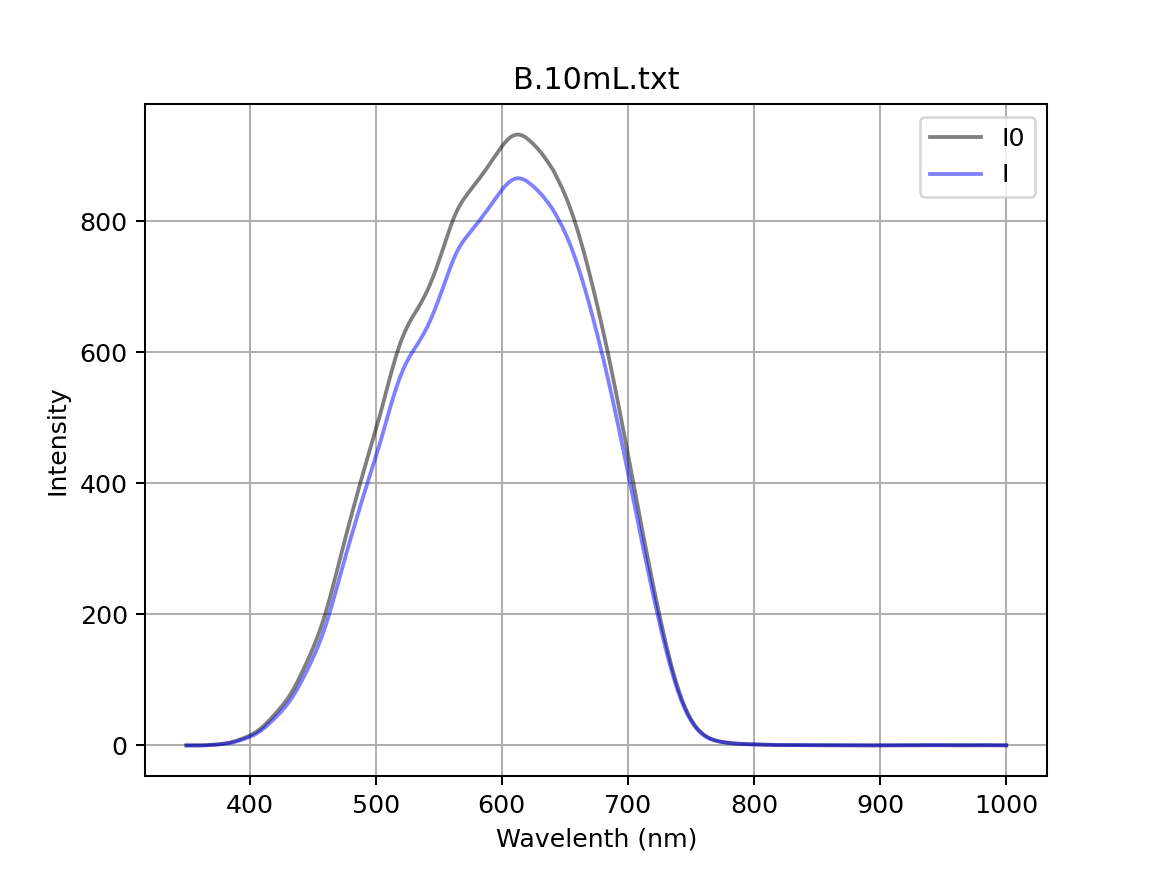

<IPython.core.display.Javascript object>


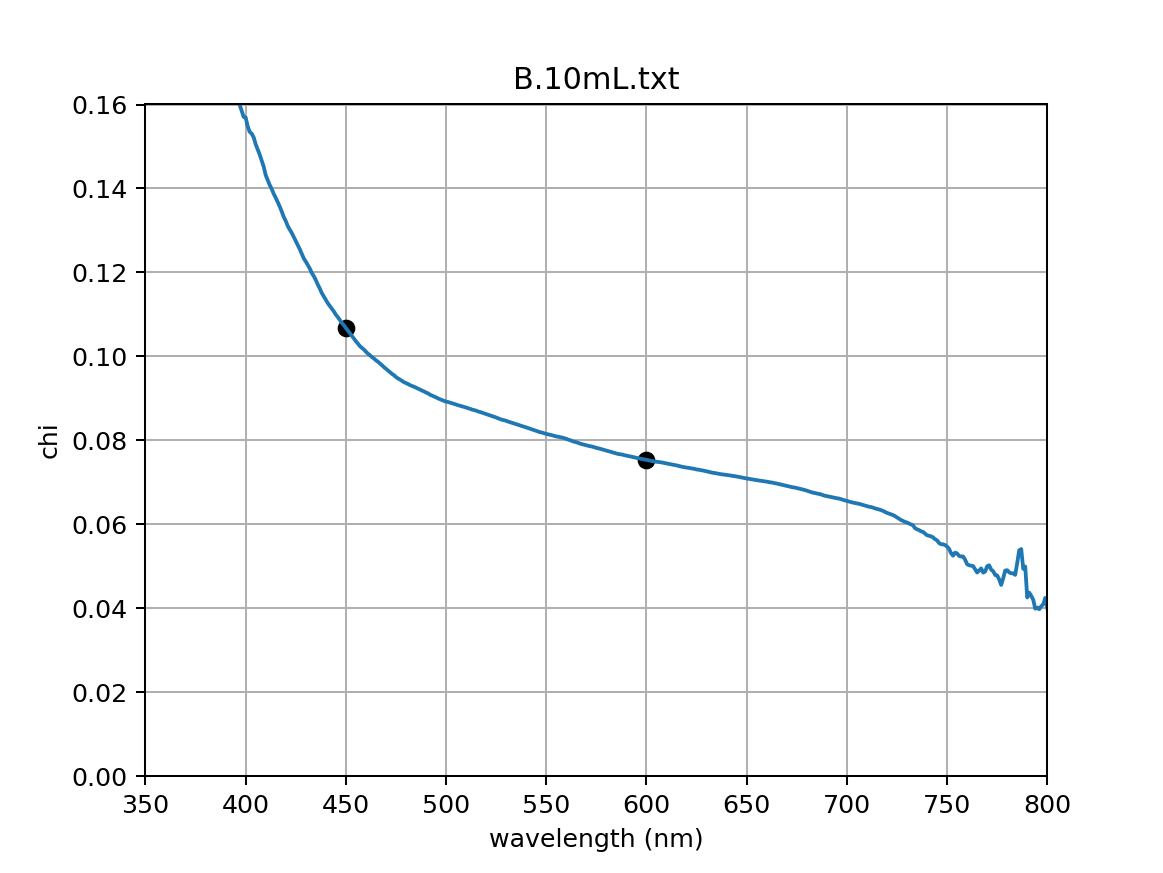

<IPython.core.display.Javascript object>


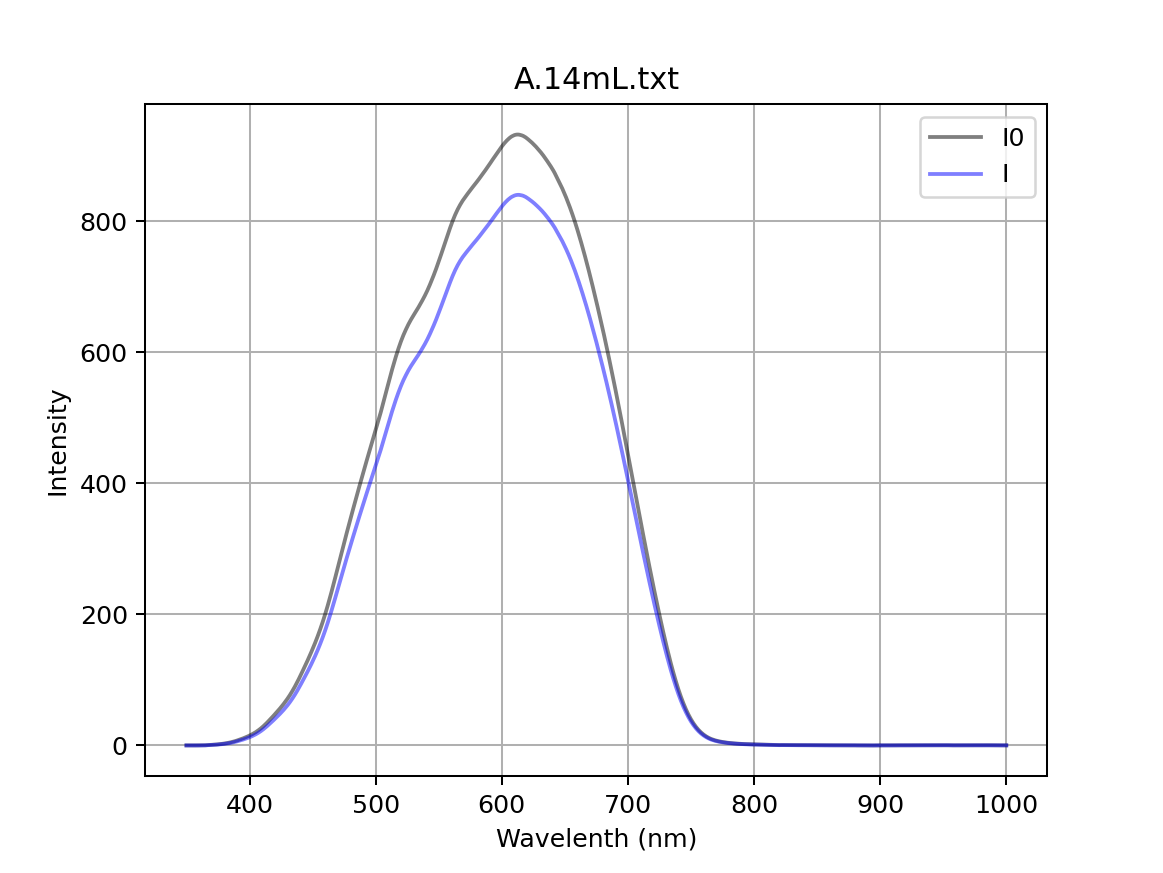

<IPython.core.display.Javascript object>


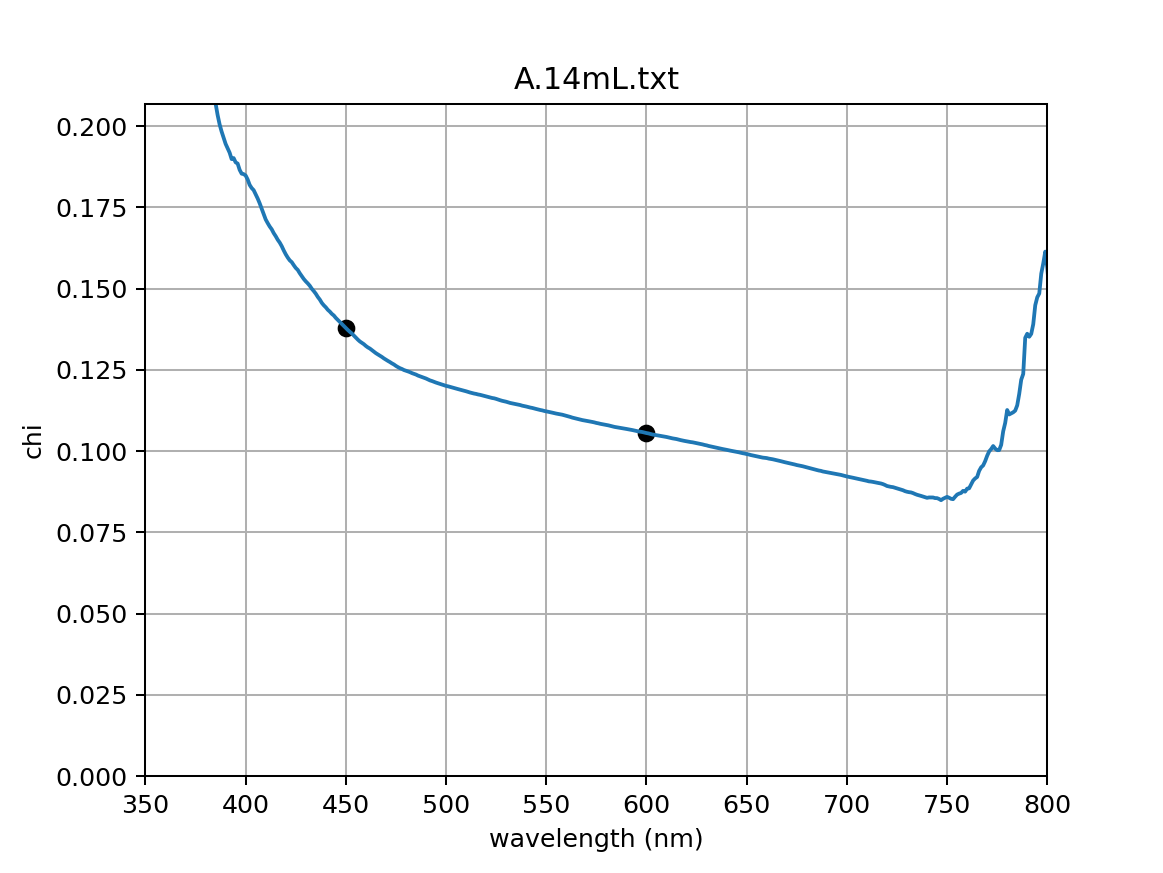

<IPython.core.display.Javascript object>


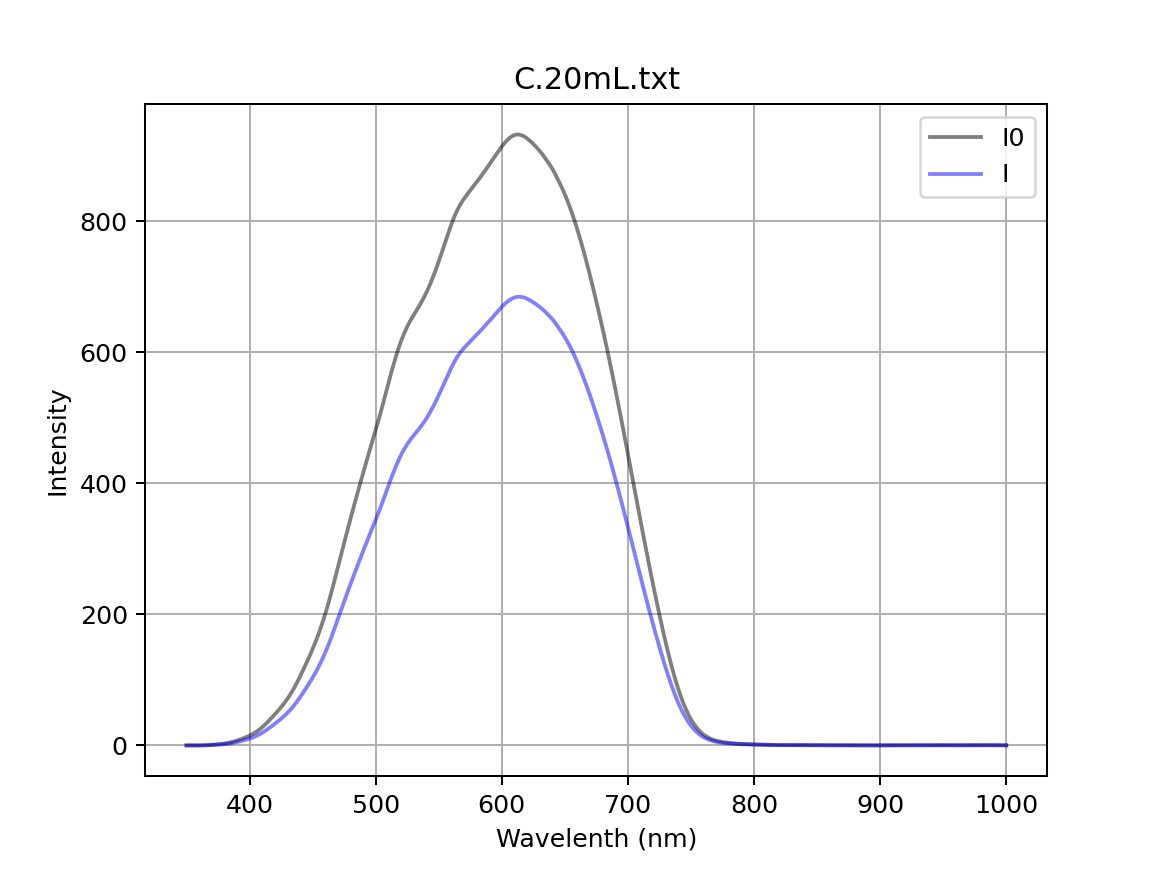

<IPython.core.display.Javascript object>


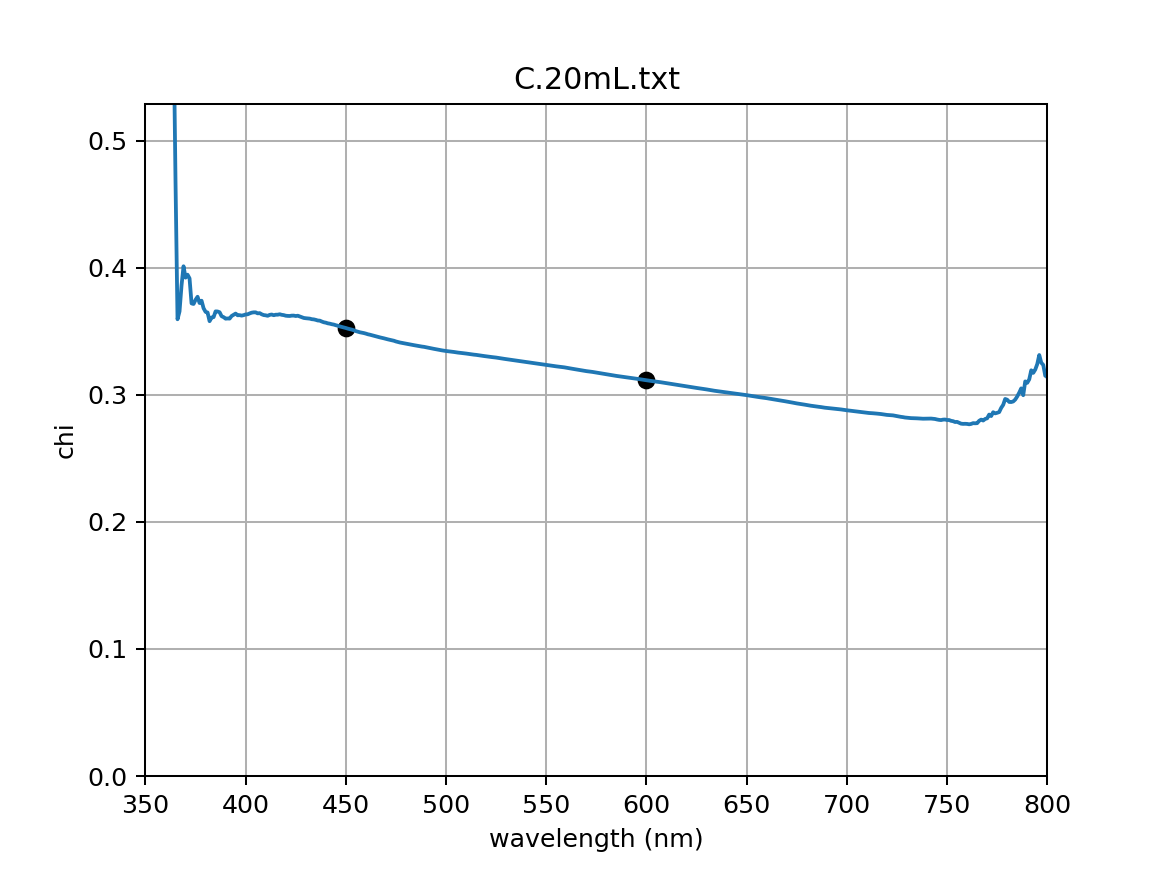

<IPython.core.display.Javascript object>


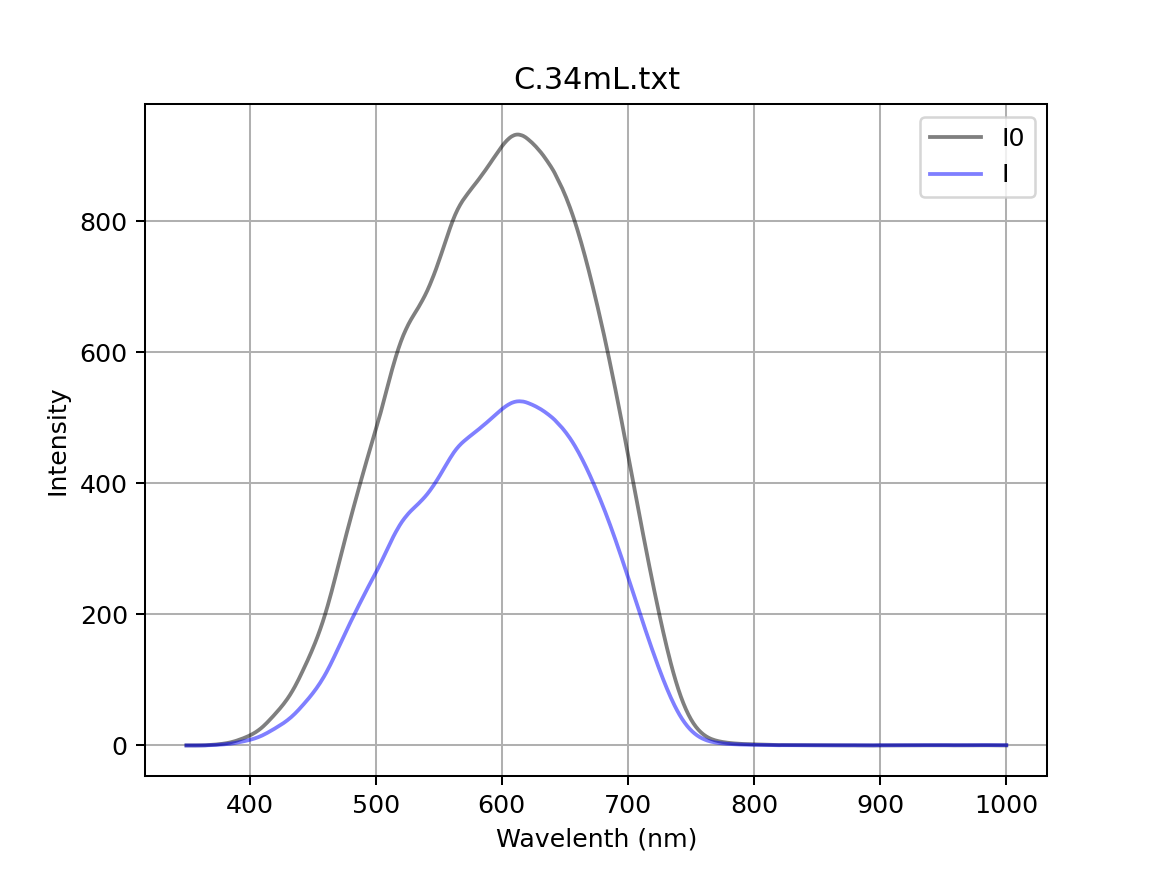

<IPython.core.display.Javascript object>


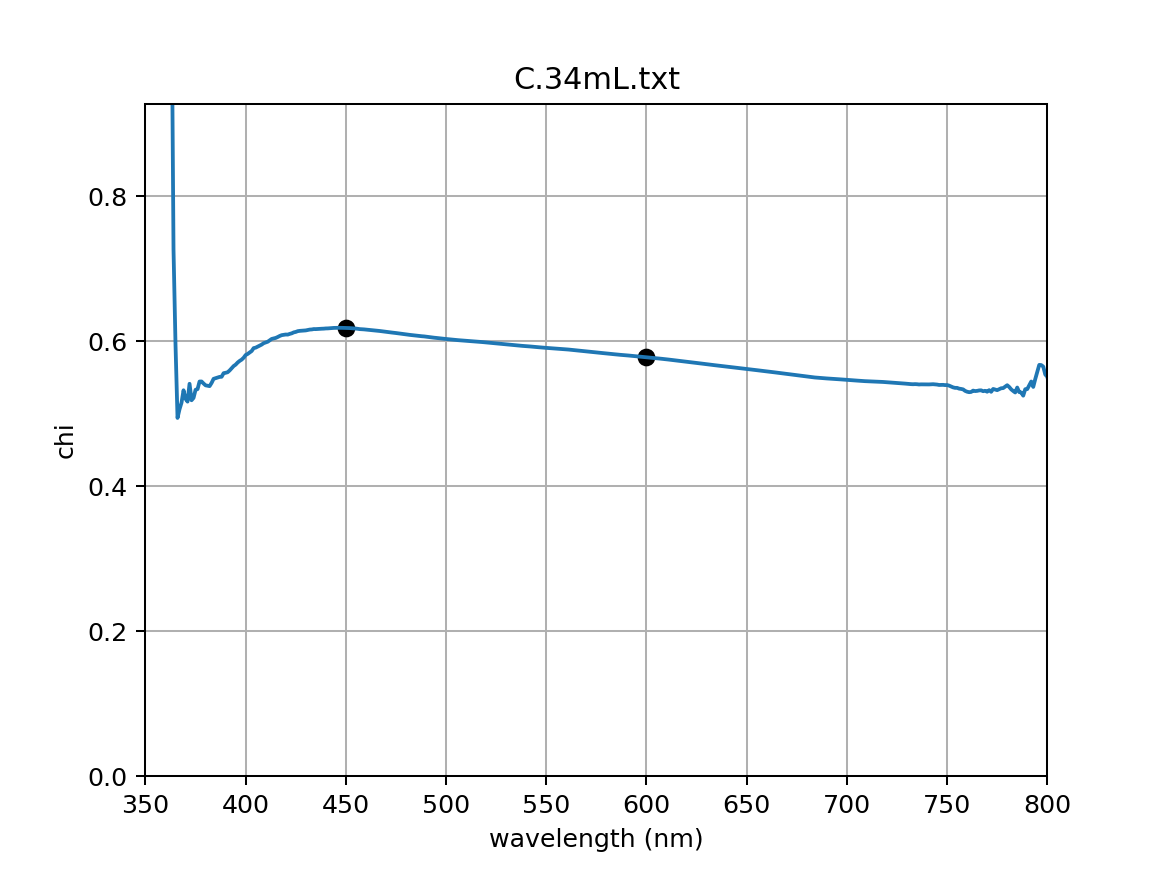

<IPython.core.display.Javascript object>


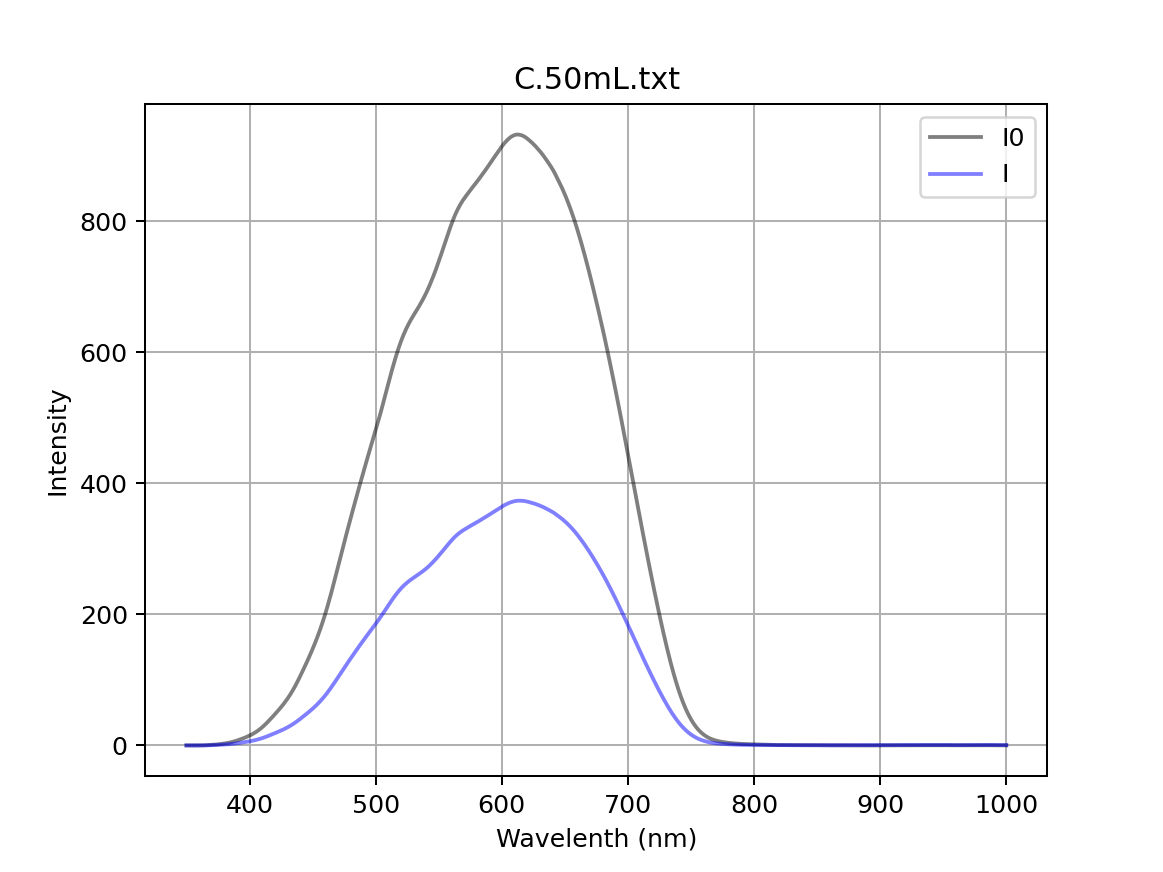

<IPython.core.display.Javascript object>


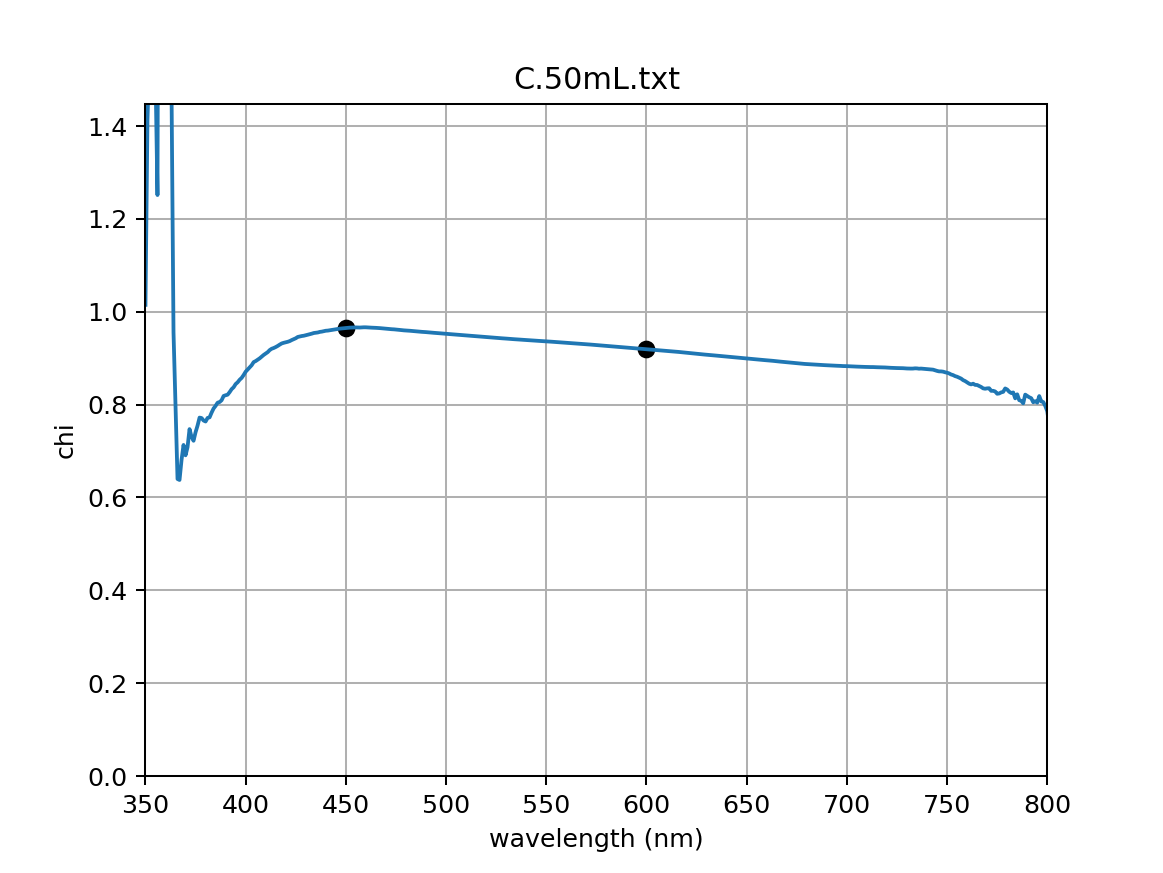

<IPython.core.display.Javascript object>


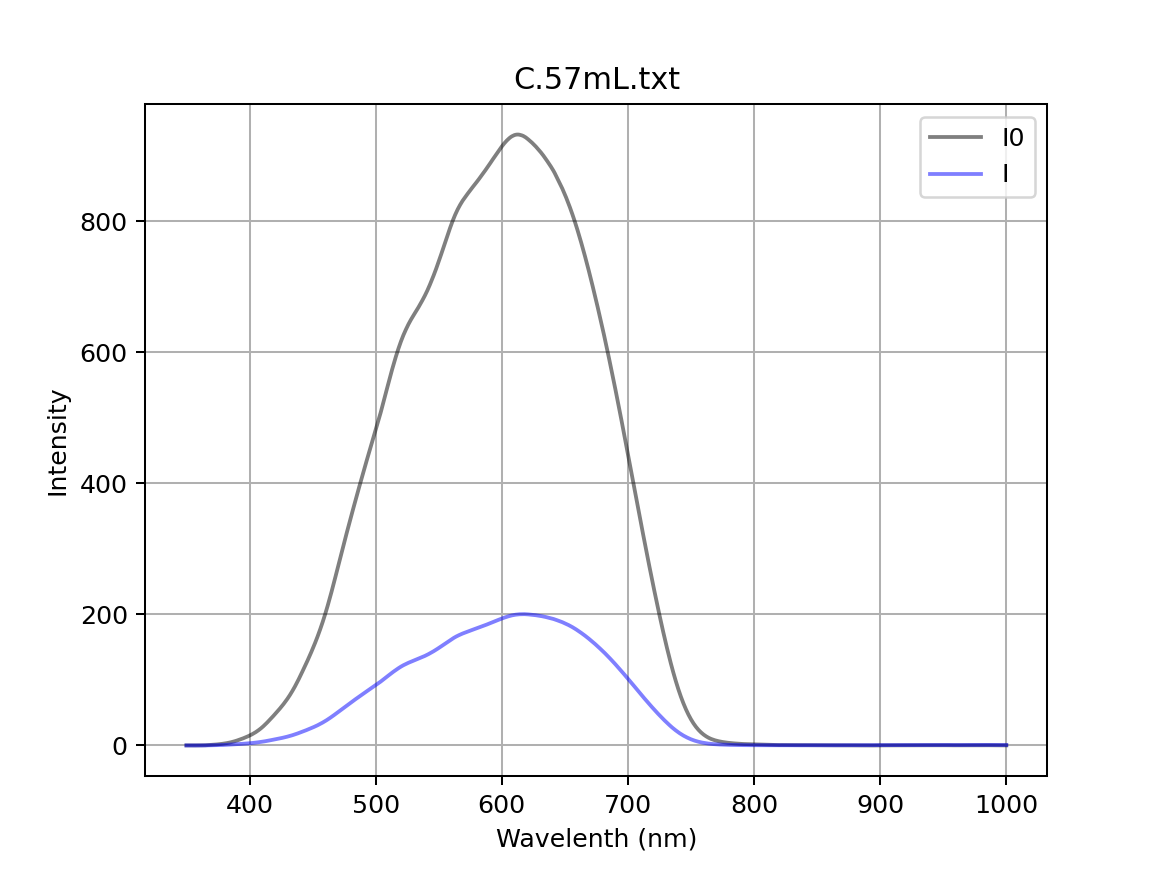

<IPython.core.display.Javascript object>


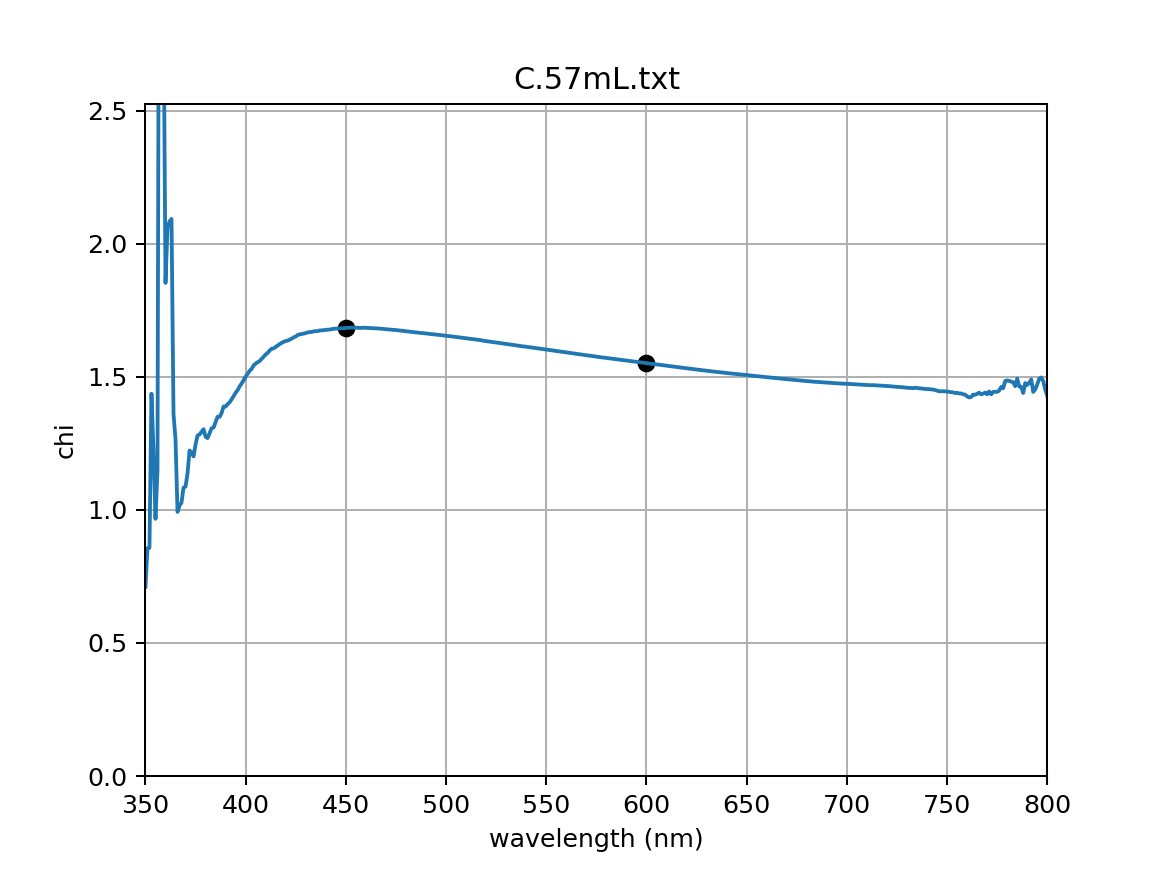

[[0.10675694 0.07533085]
 [0.13786454 0.10553502]
 [0.35274588 0.31159369]
 [0.61801001 0.57764665]
 [0.96510315 0.91957422]
 [1.68372798 1.55170354]]


In [5]:
# Get the chi-values
for i in range(number_of_loadings):
    
    # Extract the spectrum for this item in the list
    spectrum_filename = spectrum_list[i]
    lambda_nm, I_raw = IS.get_spectrum(spectrum_folder+spectrum_filename)
    
    # Smooth and shift
    I, I0 = IS.smooth_and_shift(I_raw,I0_raw)
    
    # Get observed chi
    chi = IS.get_chi_obs(I,I0,lambda_nm, title=spectrum_filename)
    
    # Save chi values at lambda1 and lambda2
    chi_observed[i,0] = chi[I_1]
    chi_observed[i,1] = chi[I_2]

print(chi_observed)

In [6]:
# Lay out a set of loading values
L_range = np.array([0.55, 0.86, 3.02, 6.34, 11.8, 25.4]) # This is in microgram/cm^2
# L_range = np.array([0.55, 0.86, 3.02, 6.34]) # This is in microgram/cm^2

# Double-checking
if len(L_range) != number_of_loadings:
    print('inconsistency')
    np.sqrt(-1)

<IPython.core.display.Javascript object>


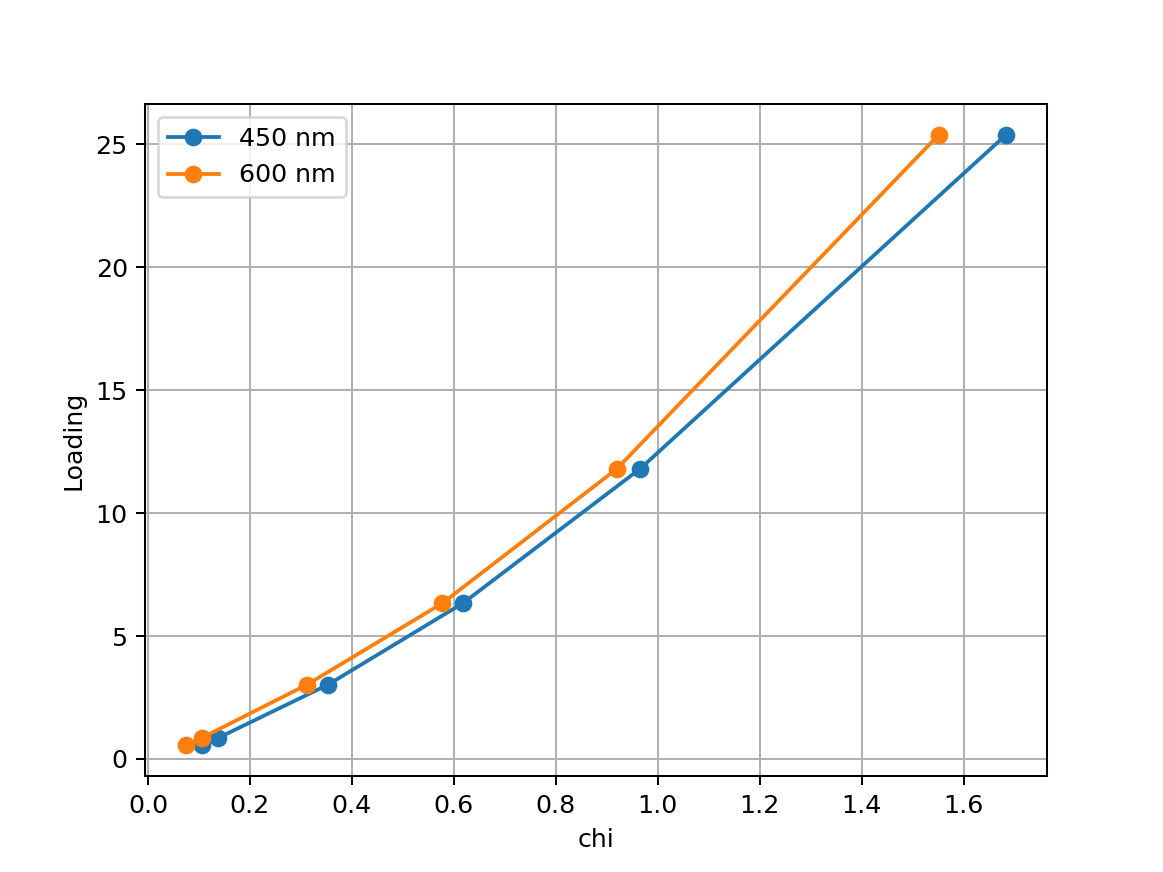

In [7]:
# Let's take a look
plt.figure()
plt.plot(chi_observed[:,0],L_range,marker='o',label='450 nm')
plt.plot(chi_observed[:,1],L_range,marker='o',label='600 nm')
plt.legend()
plt.xlabel('chi')
plt.ylabel('Loading')
plt.grid(True)

In [8]:
beta1 = 8.9 # This is in m^2/g, for 450 and 600 nm
beta2 = 6.5

### Using Tom's theory
The cell below uses Tom's formulas ... but the fit is not good, so I'm trying another approach.

In [9]:
# # Looking for optimal R1R2 values
# chi_theory = np.zeros((number_of_loadings,2))
# R1R2_range = np.linspace(0.1,.6)
# error1_range = np.zeros(np.shape(R1R2_range))
# error2_range = np.zeros(np.shape(R1R2_range))
# for iR1R2 in range(len(R1R2_range)):

#     R1R2 = R1R2_range[iR1R2]
#     for i in range(number_of_loadings):
#         L = L_range[i]
#         tau1 = L*beta1/100 # Dividing by 100 makes it dimensionless
#         tau2 = L*beta2/100
#         chi_theory[i,0] = IS.get_chi_theory(tau1,R1R2)
#         chi_theory[i,1] = IS.get_chi_theory(tau2,R1R2)
        
#     error1_range[iR1R2] = np.sum((chi_observed[:,0]-chi_theory[:,0])**2)
#     error2_range[iR1R2] = np.sum((chi_observed[:,1]-chi_theory[:,1])**2)
    
# # Let's see how we did
# plt.figure()
# plt.plot(R1R2_range,error1_range,marker='o',label='450 nm')
# plt.plot(R1R2_range,error2_range,marker='o',label='450 nm')
# plt.grid(True)
# plt.xlabel('R1R2')
# imin1 = np.argmin(error1_range); R1R2_1 = R1R2_range[imin1]
# imin2 = np.argmin(error2_range); R1R2_2 = R1R2_range[imin2]
# print('Best R1R2 = ', R1R2_1)
# print('Best R1R2 = ', R1R2_2)

# # Let's see how we did
# tau1_range = L_range*beta1/100
# tau2_range = L_range*beta2/100
# chi1_theory = IS.get_chi_theory(tau1_range,R1R2_1)
# chi2_theory = IS.get_chi_theory(tau2_range,R1R2_2)

# plt.figure()
# plt.plot(L_range,chi_observed[:,0])
# plt.plot(L_range,chi1_theory,'o')
# plt.grid(True)

# plt.figure()
# plt.plot(L_range,chi_observed[:,1])
# plt.plot(L_range,chi2_theory,'o')
# plt.grid(True)

[-0.10346643  0.61711326  0.60923147 -0.02069111]
[ 0.03272798  0.27962157  0.55558666 -0.00657447]


<IPython.core.display.Javascript object>


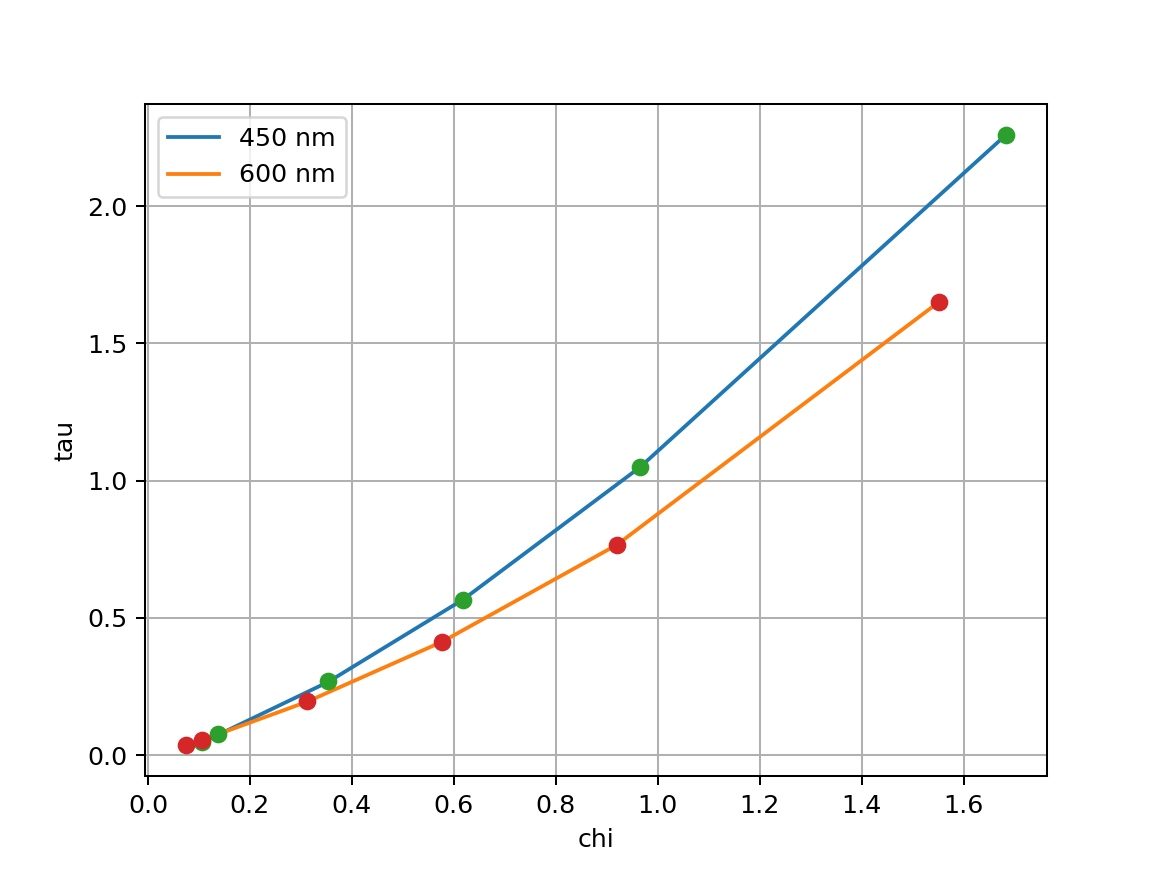

<IPython.core.display.Javascript object>


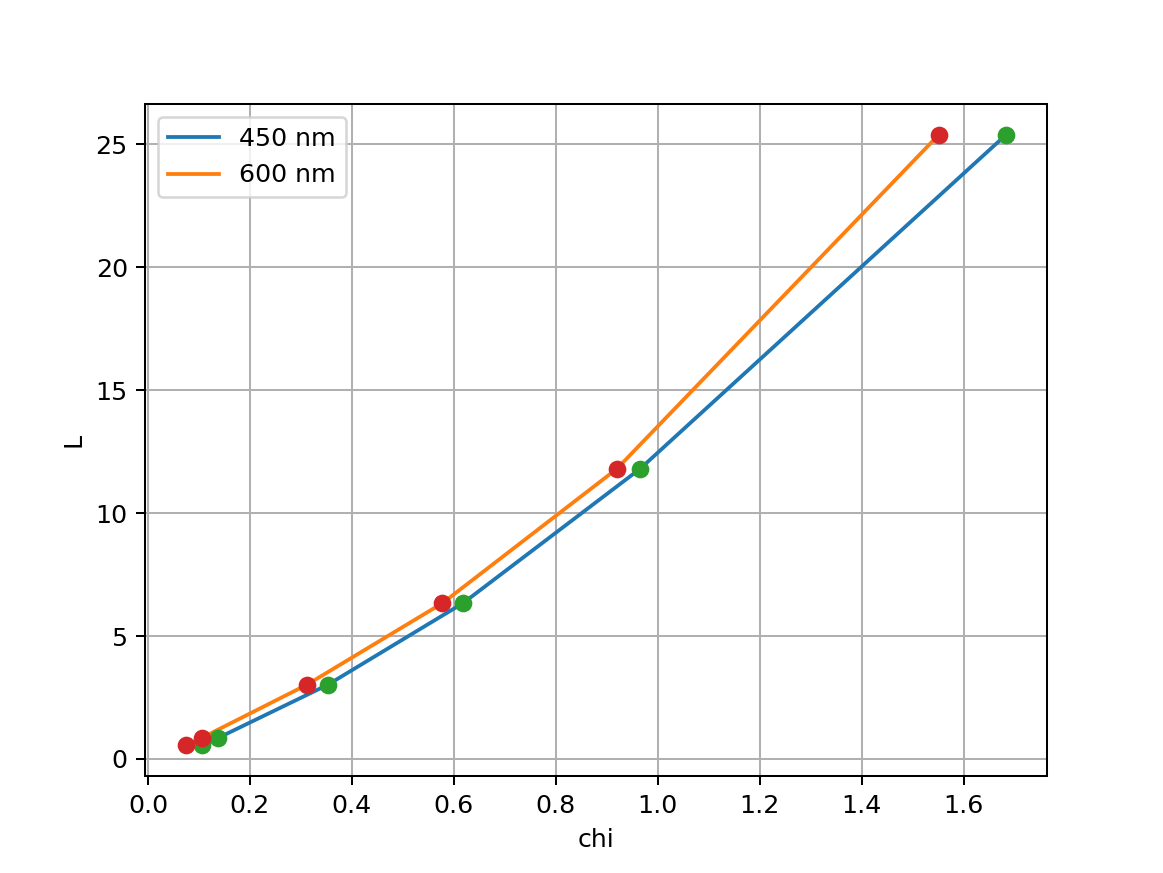

<IPython.core.display.Javascript object>


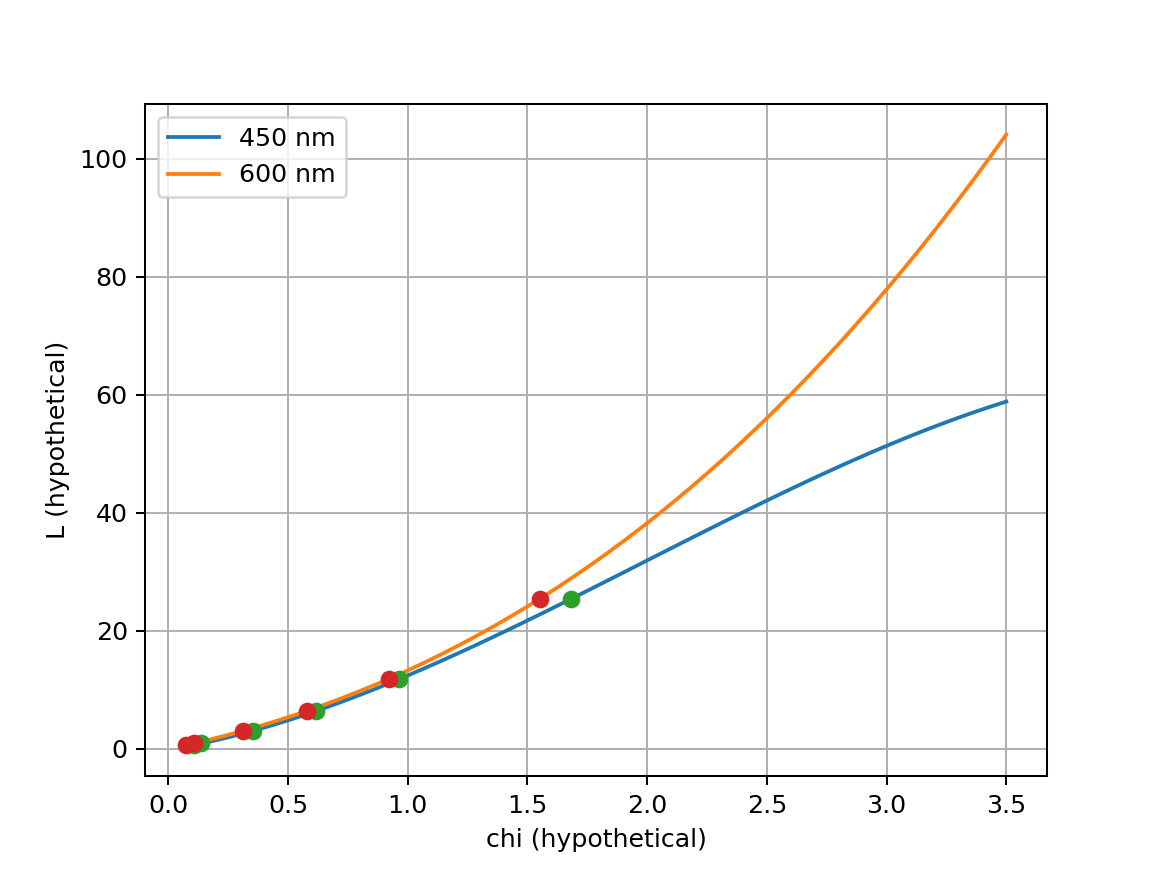

AAE =  [1.09234857 1.09234857 1.09234857 1.09234857 1.09234857 1.09234857]
AAE =  [1.14427171 1.0535192  1.0909741  1.0940414  1.09208107 1.09233295]


In [22]:
# Another approach: a polynomial fit
fit_order = 3
tau1_range = L_range*beta1/100; p_1 = np.polyfit(chi_observed[:,0],tau1_range,fit_order); print(p_1)
tau1_range_theory = np.polyval(p_1,chi_observed[:,0])
tau2_range = L_range*beta2/100; p_2 = np.polyfit(chi_observed[:,1],tau2_range,fit_order); print(p_2)
tau2_range_theory = np.polyval(p_2,chi_observed[:,1])

# See how we did
plt.figure()
plt.plot(chi_observed[:,0],tau1_range_theory,label='450 nm')
plt.plot(chi_observed[:,1],tau2_range_theory,label='600 nm')
plt.legend()
plt.plot(chi_observed[:,0],tau1_range,'o')
plt.plot(chi_observed[:,1],tau2_range,'o')
plt.xlabel('chi')
plt.ylabel('tau')
plt.grid(True)

# See how we did
plt.figure()
plt.plot(chi_observed[:,0],L_range,label='450 nm')
plt.plot(chi_observed[:,1],L_range,label='600 nm')
plt.legend()
plt.plot(chi_observed[:,0],L_range,'o')
plt.plot(chi_observed[:,1],L_range,'o')
plt.xlabel('chi')
plt.ylabel('L')
plt.grid(True)

# See how well-behaved these coefficients are
chi_hypothetical = np.linspace(0.1,3.5)
tau1_range_hypothetical = np.polyval(p_1,chi_hypothetical)
tau2_range_hypothetical = np.polyval(p_2,chi_hypothetical)
L1_range_hypothetical = tau1_range_hypothetical*100/beta1
L2_range_hypothetical = tau2_range_hypothetical*100/beta2
plt.figure()
plt.plot(chi_hypothetical,L1_range_hypothetical,label='450 nm')
plt.plot(chi_hypothetical,L2_range_hypothetical,label='600 nm')
plt.legend()
plt.plot(chi_observed[:,0],tau1_range*100/beta1,'o')
plt.plot(chi_observed[:,1],tau2_range*100/beta2,'o')
plt.xlabel('chi (hypothetical)')
plt.ylabel('L (hypothetical)')
plt.grid(True)

# Calculate some Angstrom exponents
top = np.log(tau1_range/tau2_range)
bot = np.log(lambda_nm[I_1]/lambda_nm[I_2])
AAE = -top/bot; print('AAE = ', AAE)

top = np.log(tau1_range_theory/tau2_range_theory)
bot = np.log(lambda_nm[I_1]/lambda_nm[I_2])
AAE = -top/bot; print('AAE = ', AAE)
